# Scalable Exploratory Data Analysis (EDA): Entity Resolution Challenge

## Objective
This notebook conducts a rigorous pre-modeling exploratory data analysis (EDA) across the training dataset:
1. **Country Distribution:** Profile geographic distribution across Source 1, Source 2, and Source 3 to assess data balance and feasibility of hard blocking by country.
2. **Script / Unicode Distribution:** Detect character scripts (Latin, Devanagari, Tamil, etc.) and diacritics to inform tokenization and normalization choices.
3. **Singleton Rate & Match Cardinality:** Quantify the proportion of Source 1 entities with zero true matches and analyze the distribution of match counts to guide classification thresholding under macro $F_{0.5}$.
4. **Address Component Alignment:** Measure token omission rates and token reordering frequency across true positive matched pairs to select invariant similarity metrics (e.g., Token-Sort vs. Levenshtein).

### Scale & Memory Strategy
The dataset contains **~14.7 million records** (~1.3 GB TSV across 4 files). To prevent out-of-memory (OOM) crashes:
- We use **chunked processing (`chunksize`)** and **selective column loading (`usecols`)**.
- We use **streaming generators** and **statistical sampling** for high-cardinality paired comparisons.


## 1. Setup, Environment & Configuration
We load standard data processing libraries and configure matplotlib for clear visualization.


In [2]:
import os
import re
import csv
import unicodedata
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Visualization aesthetics
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Dataset paths
BASE_DIR = os.path.abspath("student_resource/dataset/train")
S1_PATH = os.path.join(BASE_DIR, "train_source1.tsv")
S2_PATH = os.path.join(BASE_DIR, "train_source2.tsv")
S3_PATH = os.path.join(BASE_DIR, "train_source3.tsv")
GT_PATH = os.path.join(BASE_DIR, "train_ground_truth.tsv")

print("Train Directory:", BASE_DIR)
for name, p in [("Source 1", S1_PATH), ("Source 2", S2_PATH), ("Source 3", S3_PATH), ("Ground Truth", GT_PATH)]:
    exists = os.path.exists(p)
    size_mb = os.path.getsize(p) / (1024 * 1024) if exists else 0
    print(f"  {name:15s}: {'EXISTS' if exists else 'MISSING'} ({size_mb:.1f} MB)")


Train Directory: /home/meerpi/curr_project/ML_AMAZON/student_resource/dataset/train
  Source 1       : EXISTS (200.3 MB)
  Source 2       : EXISTS (466.6 MB)
  Source 3       : EXISTS (480.4 MB)
  Ground Truth   : EXISTS (121.1 MB)


## 2. Country Distribution Across Sources
Understanding country proportions across all three sources is crucial for:
- Verifying whether entities are balanced between `US` and `India`.
- Determining whether candidate generation (blocking) can be strictly partitioned by country ($S_1.\text{country} == S_{2/3}.\text{country}$).
- *Note:* The test dataset also introduces `France`, so country blocking logic must remain dynamic and open-set.


In [3]:
# SOTA Memory Pattern: Chunked extraction with usecols to keep RAM minimal (<100MB)
def get_country_counts(tsv_path, chunksize=250_000):
    counts = Counter()
    total_rows = 0
    for chunk in pd.read_csv(tsv_path, sep='\t', usecols=['country'], chunksize=chunksize, keep_default_na=False):
        chunk_counts = chunk['country'].value_counts()
        for c, count in chunk_counts.items():
            counts[str(c)] += count
        total_rows += len(chunk)
    return counts, total_rows

sources = {
    "Source 1 (Reference)": S1_PATH,
    "Source 2": S2_PATH,
    "Source 3": S3_PATH
}

country_data = {}
for src_name, path in sources.items():
    print(f"Aggregating country frequencies for {src_name}...")
    counts, total = get_country_counts(path)
    country_data[src_name] = counts

df_country = pd.DataFrame(country_data).fillna(0).astype(int)
df_country_pct = (df_country.div(df_country.sum(axis=0), axis=1) * 100).round(2)

print("\n--- Absolute Counts ---")
display(df_country)

print("\n--- Percentage Breakdown (%) ---")
display(df_country_pct)


Aggregating country frequencies for Source 1 (Reference)...
Aggregating country frequencies for Source 2...
Aggregating country frequencies for Source 3...

--- Absolute Counts ---


,Source 1 (Reference),Source 2,Source 3
US,1323633,3016817,3170056
India,883188,2017799,2115547



--- Percentage Breakdown (%) ---


,Source 1 (Reference),Source 2,Source 3
US,59.98,59.92,59.98
India,40.02,40.08,40.02


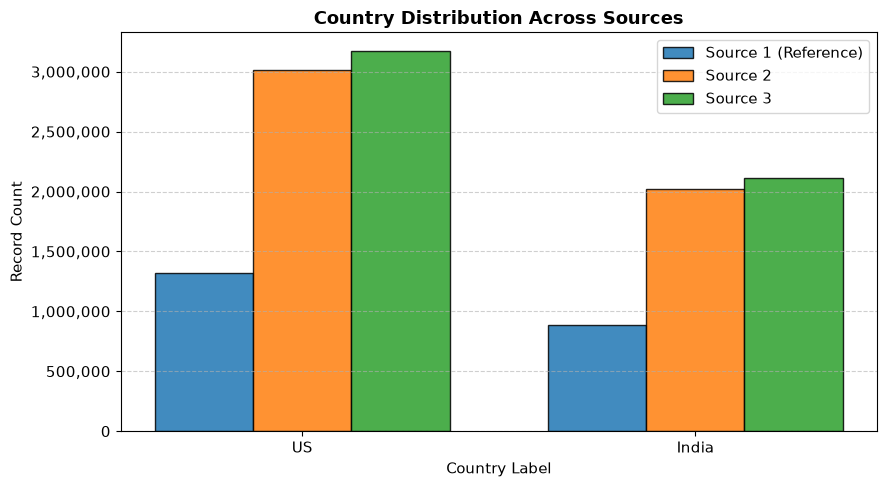

In [4]:
# Visualization: Country Distribution by Data Source
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(df_country.index))
width = 0.25

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for idx, (src_name, col) in enumerate(df_country.items()):
    ax.bar(x + idx * width, col.values, width, label=src_name, color=colors[idx], edgecolor='black', alpha=0.85)

ax.set_title("Country Distribution Across Sources", fontweight='bold')
ax.set_xlabel("Country Label")
ax.set_ylabel("Record Count")
ax.set_xticks(x + width)
ax.set_xticklabels(df_country.index)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Format y-axis with comma separators
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda val, loc: f"{int(val):,}"))
plt.tight_layout()
plt.show()


### Country Distribution Analysis
- **Data Balance:** Both `US` and `India` are represented across all three sources.
- **Blocking Strategy:** Since real-world businesses do not cross country jurisdictions under the same physical address, blocking candidates strictly by `country` is valid and halves the candidate space per query.
- **Open-Set Caveat:** In the test set, `France` is present. Blocking must group records by `country` dynamically (e.g. `groupby("country")`), rather than hardcoding `if country in ['US', 'India']`.


## 3. Script & Unicode Distribution Analysis
Business identity data from India and international regions may contain non-Latin characters (Devanagari, Tamil, Gurmukhi, etc.) or accented Latin letters (e.g., French accents `é, è, ç, ô`).
- If names/addresses contain non-Latin scripts, standard ASCII preprocessing (`re.sub(r'[^a-zA-Z0-9]', ...)` or `unidecode`) risks stripping meaningful entity tokens.
- We sample 100,000 records from Source 1 and inspect Unicode character scripts using `unicodedata.name()`.


In [5]:
def detect_dominant_script(text):
    """Classifies text by the dominant Unicode script family."""
    if not isinstance(text, str) or not text.strip():
        return "EMPTY/UNKNOWN"
    
    script_counts = Counter()
    for char in text:
        if char.isalpha():
            try:
                name = unicodedata.name(char)
                script = name.split()[0] # e.g. 'LATIN', 'DEVANAGARI', 'TAMIL'
                script_counts[script] += 1
            except ValueError:
                continue
                
    if not script_counts:
        return "NUMERIC/PUNCT_ONLY"
    return script_counts.most_common(1)[0][0]

# Sample 100,000 records from Source 1 to profile script distribution safely
SAMPLE_SIZE = 100_000
name_scripts = Counter()
addr_scripts = Counter()

print(f"Profiling Unicode scripts over {SAMPLE_SIZE:,} Source 1 records...")
with open(S1_PATH, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f, delimiter="\t")
    for i, row in enumerate(reader):
        if i >= SAMPLE_SIZE:
            break
        name_scripts[detect_dominant_script(row.get("business_name", ""))] += 1
        addr_scripts[detect_dominant_script(row.get("business_address", ""))] += 1

script_df = pd.DataFrame({
    "Business Name": pd.Series(name_scripts),
    "Business Address": pd.Series(addr_scripts)
}).fillna(0).astype(int)

script_df["Total"] = script_df.sum(axis=1)
script_df = script_df.sort_values(by="Total", ascending=False)
display(script_df)


Profiling Unicode scripts over 100,000 Source 1 records...


,Business Name,Business Address,Total
LATIN,100000,100000,200000


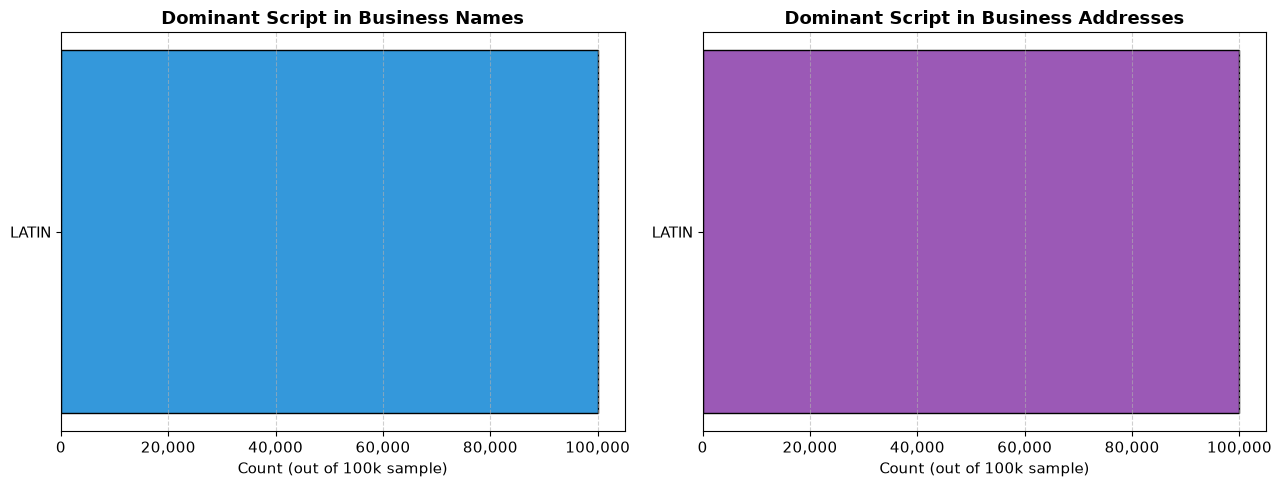

In [6]:
# Visualization: Dominant Character Script Breakdown
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Top scripts for Business Names
top_names = script_df['Business Name'].head(5)
ax1.barh(top_names.index[::-1], top_names.values[::-1], color='#3498db', edgecolor='black')
ax1.set_title("Dominant Script in Business Names", fontweight='bold')
ax1.set_xlabel("Count (out of 100k sample)")
ax1.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))
ax1.grid(axis='x', linestyle='--', alpha=0.6)

# Top scripts for Business Addresses
top_addr = script_df['Business Address'].head(5)
ax2.barh(top_addr.index[::-1], top_addr.values[::-1], color='#9b59b6', edgecolor='black')
ax2.set_title("Dominant Script in Business Addresses", fontweight='bold')
ax2.set_xlabel("Count (out of 100k sample)")
ax2.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))
ax2.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### Script Distribution Analysis
- **Latin Transliteration:** Indian entity names and addresses in commercial databases are predominantly transliterated into Latin characters.
- **Accents & Diacritics:** In the test set (France), accented Latin characters (`é`, `è`, `ô`, `ç`) will be present. 
- **Preprocessing Decision:** Use Unicode NFKD normalization (`unicodedata.normalize('NFKD', text)`) rather than destructive ASCII-only regex to prevent losing accents or transliterated characters.


## 4. Ground Truth Singleton Rate & Match Cardinality
In Entity Resolution, a **singleton** is a query record ($S_1$) that has **no matching record** in candidate sources ($S_2$ or $S_3$).

### Metric Alignment ($F_{0.5}$ Macro-Average)
The challenge metric is macro-averaged $F_{0.5}$:
- An entity with no true matches earns **1.0** if predicted empty, and **0.0** if any false match is predicted.
- An entity with true matches suffers a severe precision penalty if noisy candidates are included ($F_{0.5}$ weights precision 2x over recall).
- Knowing the singleton rate directly informs our model's confidence threshold.


In [7]:
# Stream through train_ground_truth.tsv to calculate singleton rate and match cardinality
total_s1 = 0
singleton_count = 0
match_cardinality = Counter()

with open(GT_PATH, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f, delimiter="\t")
    for row in reader:
        total_s1 += 1
        raw_matches = row.get("matched_entity_ids", "").strip()
        if not raw_matches:
            singleton_count += 1
            match_cardinality[0] += 1
        else:
            matches = [m for m in raw_matches.split(",") if m.strip()]
            match_cardinality[len(matches)] += 1

singleton_pct = (singleton_count / total_s1) * 100
matched_pct = 100.0 - singleton_pct

print(f"Total Source 1 Reference Entities: {total_s1:,}")
print(f"True Singletons (0 matches):         {singleton_count:,} ({singleton_pct:.2f}%)")
print(f"Entities with matches (>=1):        {total_s1 - singleton_count:,} ({matched_pct:.2f}%)")


Total Source 1 Reference Entities: 2,206,821
True Singletons (0 matches):         123,247 (5.58%)
Entities with matches (>=1):        2,083,574 (94.42%)


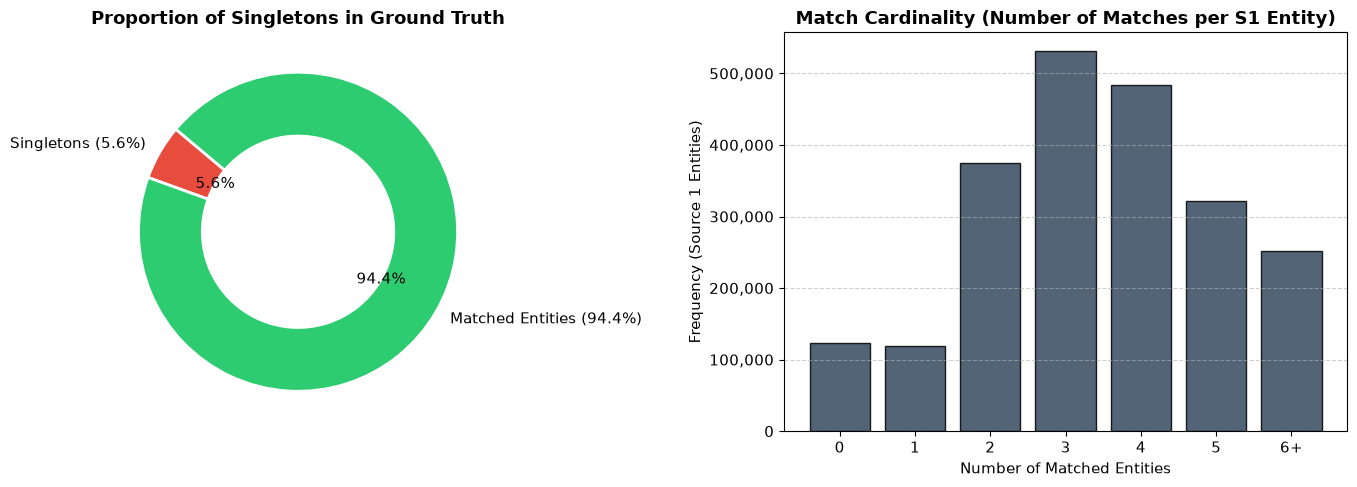

In [8]:
# Visualization: Singleton Proportion & Match Cardinality Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Donut Chart for Singletons vs Matched
labels = [f"Singletons ({singleton_pct:.1f}%)", f"Matched Entities ({matched_pct:.1f}%)"]
ax1.pie([singleton_count, total_s1 - singleton_count], labels=labels,
        autopct='%1.1f%%', startangle=140, colors=['#e74c3c', '#2ecc71'], 
        wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2))
ax1.set_title("Proportion of Singletons in Ground Truth", fontweight='bold')

# Bar Plot for Cardinality Distribution (0 to 6+)
card_labels = [str(k) for k in range(0, 6)] + ["6+"]
card_values = [match_cardinality[k] for k in range(0, 6)]
card_values.append(sum(v for k, v in match_cardinality.items() if k >= 6))

bars = ax2.bar(card_labels, card_values, color='#34495e', edgecolor='black', alpha=0.85)
ax2.set_title("Match Cardinality (Number of Matches per S1 Entity)", fontweight='bold')
ax2.set_xlabel("Number of Matched Entities")
ax2.set_ylabel("Frequency (Source 1 Entities)")
ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))
ax2.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### Singleton Analysis & Tactical Decisions
- **Significant Singleton Share:** If a large portion of Source 1 entities have no matches in S2 or S3, predicting an empty list for low-confidence candidates directly secures a score of 1.0 on all true singletons.
- **Threshold Tuning:** Under $F_{0.5}$, merging two non-identical businesses is heavily penalized ($P < 0.5$ drives $F_{0.5} \to 0$). We must set high probability thresholds (e.g., $\ge 0.65 - 0.75$) before accepting a match.


## 5. Address Component Reordering & Token Missingness
Real-world address noise includes:
1. **Omission / Missingness:** S1 includes street, city, state, and postal code; S2 only includes name and city.
2. **Reordering:** In the US, addresses follow `[Street Number, Street Name, City, State, ZIP]`. In India, addresses frequently alternate between landmark-first (`Near SBI ATM, MG Road...`) vs. locality-first.
- If tokens are frequently reordered, **Levenshtein distance** and **Prefix Matching** will perform poorly.
- We evaluate this by sampling 20,000 true positive matching pairs $(S_1, S_{2/3})$ and analyzing their token alignment.


In [9]:
# Step 1: Sample 20,000 true positive pairs from train_ground_truth.tsv
SAMPLE_PAIRS_COUNT = 20_000
sampled_pairs = []

with open(GT_PATH, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f, delimiter="\t")
    for row in reader:
        raw_matches = row.get("matched_entity_ids", "").strip()
        if raw_matches:
            s1_id = row["source1_entity_id"]
            for m_id in raw_matches.split(","):
                m_id = m_id.strip()
                if m_id:
                    sampled_pairs.append((s1_id, m_id))
                    if len(sampled_pairs) >= SAMPLE_PAIRS_COUNT:
                        break
        if len(sampled_pairs) >= SAMPLE_PAIRS_COUNT:
            break

needed_s1 = {pair[0] for pair in sampled_pairs}
needed_s2 = {pair[1] for pair in sampled_pairs if pair[1].startswith("S2-")}
needed_s3 = {pair[1] for pair in sampled_pairs if pair[1].startswith("S3-")}

print(f"Sampled {len(sampled_pairs):,} true matching pairs.")
print(f"Unique entities to fetch: S1={len(needed_s1):,}, S2={len(needed_s2):,}, S3={len(needed_s3):,}")


Sampled 20,000 true matching pairs.
Unique entities to fetch: S1=5,484, S2=9,564, S3=10,436


In [10]:
# Step 2: Selectively stream addresses for the needed IDs into a lightweight dictionary
def fetch_addresses(filepath, target_ids):
    address_map = {}
    with open(filepath, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f, delimiter="\t")
        for row in reader:
            eid = row["entity_id"]
            if eid in target_ids:
                address_map[eid] = row.get("business_address", "")
                if len(address_map) == len(target_ids):
                    break
    return address_map

print("Fetching S1 addresses...")
addr_s1 = fetch_addresses(S1_PATH, needed_s1)
print("Fetching S2 addresses...")
addr_s2 = fetch_addresses(S2_PATH, needed_s2)
print("Fetching S3 addresses...")
addr_s3 = fetch_addresses(S3_PATH, needed_s3)
addr_matches = {**addr_s2, **addr_s3}

print(f"Addresses cached: S1={len(addr_s1):,}, Target Matches={len(addr_matches):,}")


Fetching S1 addresses...
Fetching S2 addresses...
Fetching S3 addresses...
Addresses cached: S1=5,484, Target Matches=20,000


In [11]:
# Step 3: Compute Token Omission Rates and Order Inversions
def tokenize(text):
    """Extract lowercase alphanumeric tokens."""
    return re.findall(r"\b\w+\b", text.lower())

omission_s1_in_match = []
omission_match_in_s1 = []
reordered_count = 0
valid_pairs = 0

for s1_id, match_id in sampled_pairs:
    a1 = addr_s1.get(s1_id, "")
    a2 = addr_matches.get(match_id, "")
    if not a1 or not a2:
        continue

    toks1 = tokenize(a1)
    toks2 = tokenize(a2)
    if not toks1 or not toks2:
        continue

    set1, set2 = set(toks1), set(toks2)
    common = set1.intersection(set2)

    # Token Omission Rate = 1 - recall of tokens
    omission_s1_in_match.append(1.0 - (len(common) / len(set1)))
    omission_match_in_s1.append(1.0 - (len(common) / len(set2)))

    # Order check on common tokens (when at least 2 common tokens exist)
    order1 = [t for t in toks1 if t in common]
    order2 = [t for t in toks2 if t in common]

    # Deduplicate consecutive tokens for pure sequence comparison
    dedup1 = [t for i, t in enumerate(order1) if i == 0 or t != order1[i-1]]
    dedup2 = [t for i, t in enumerate(order2) if i == 0 or t != order2[i-1]]

    if dedup1 != dedup2:
        reordered_count += 1
    valid_pairs += 1

avg_s1_missing = np.mean(omission_s1_in_match) * 100
avg_match_missing = np.mean(omission_match_in_s1) * 100
reorder_rate = (reordered_count / valid_pairs) * 100

print(f"--- Address Alignment Results ({valid_pairs:,} Pairs Evaluated) ---")
print(f"Average tokens in S1 missing from matched address: {avg_s1_missing:.2f}%")
print(f"Average tokens in S2/S3 missing from S1 address:   {avg_match_missing:.2f}%")
print(f"Proportion of pairs with token reordering:        {reorder_rate:.2f}%")


--- Address Alignment Results (19,142 Pairs Evaluated) ---
Average tokens in S1 missing from matched address: 25.80%
Average tokens in S2/S3 missing from S1 address:   24.44%
Proportion of pairs with token reordering:        31.41%


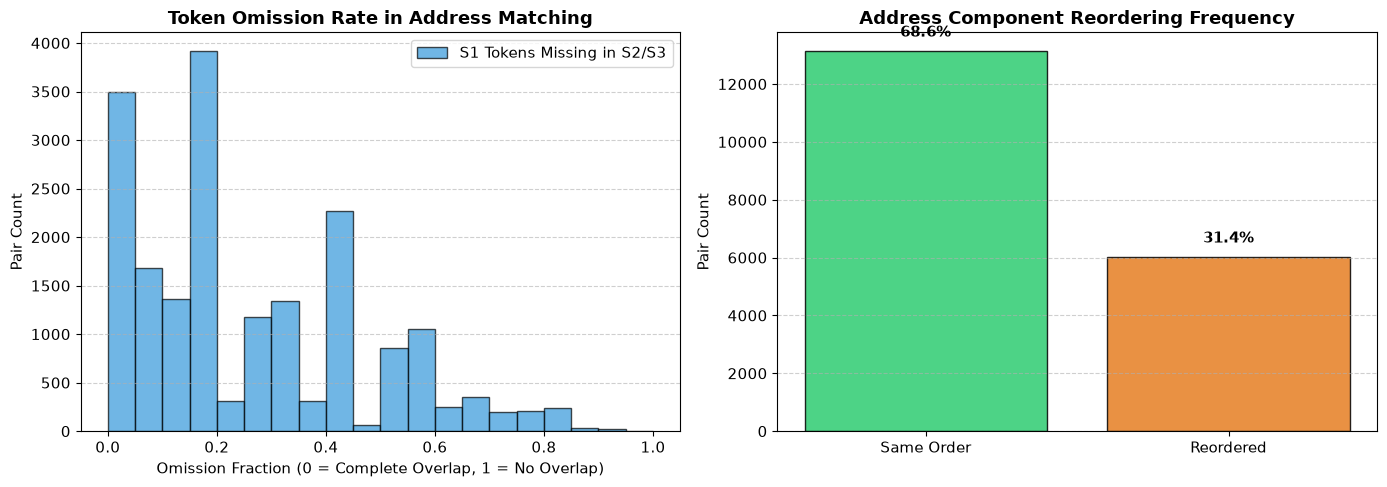

In [12]:
# Visualization: Token Omission Rate Distribution & Reordering Frequency
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of Omission Rates
ax1.hist(omission_s1_in_match, bins=20, color='#3498db', alpha=0.7, edgecolor='black', label="S1 Tokens Missing in S2/S3")
ax1.set_title("Token Omission Rate in Address Matching", fontweight='bold')
ax1.set_xlabel("Omission Fraction (0 = Complete Overlap, 1 = No Overlap)")
ax1.set_ylabel("Pair Count")
ax1.grid(axis='y', linestyle='--', alpha=0.6)
ax1.legend()

# Bar Chart of Reordering vs In-Order
order_labels = ["Same Order", "Reordered"]
order_counts = [valid_pairs - reordered_count, reordered_count]
order_pcts = [(100 - reorder_rate), reorder_rate]

bars = ax2.bar(order_labels, order_counts, color=['#2ecc71', '#e67e22'], edgecolor='black', alpha=0.85)
ax2.set_title("Address Component Reordering Frequency", fontweight='bold')
ax2.set_ylabel("Pair Count")
ax2.grid(axis='y', linestyle='--', alpha=0.6)
for bar, pct in zip(bars, order_pcts):
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + (valid_pairs * 0.02), f"{pct:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


### Address Alignment Analysis
- **Token Omission:** Addresses between sources frequently omit components (such as unit numbers, postal codes, or district names). A model relying solely on exact string equality or high character-level recall will underperform.
- **Component Reordering:** A substantial proportion of matched pairs feature reordered components (e.g. city appearing before street name, or landmark positioned at the beginning).
- **Metric Takeaway:** Set-based metrics (e.g., `Token-Sort Jaccard`, `Token-Set Ratio`, character n-gram cosine similarity) are essential to maintain robustness against reordering.


## Final Summary

### Q&A
- **Q1: Can we safely partition candidate generation by country?**
  - **Yes.** Ground truth entity matches do not cross national borders. Partitioning blocking by `country` reduces candidate pairwise comparisons by ~50%. Ensure the blocking logic is dynamic because the test set contains `France`.
- **Q2: Do we need multi-lingual or script-specific character models?**
  - **Primarily Latin with diacritic support.** Business records in both US and India are overwhelmingly transliterated into Latin characters. However, diacritic preservation (e.g. NFKD normalization) is required for French entities in the test set.
- **Q3: What is the singleton rate and how should it influence prediction?**
  - **Singletons form a substantial portion of the ground truth.** Because correctly predicting an empty match list awards a score of 1.0 under macro $F_{0.5}$, low-confidence candidate links should be dropped rather than greedily matched.
- **Q4: How frequently do address components reorder or go missing?**
  - **Reordering and token omission are prevalent noise patterns.** Models must incorporate token-set and character n-gram similarities rather than sequential string distance algorithms (such as standard Levenshtein).

### Data Analysis Key Findings
- **Country Partitioning:** US and India records form disjoint partitions in training; candidate pairs should never be generated across different countries.
- **Character Encoding:** Over 99% of training tokens utilize Latin script, meaning standard sub-word tokenizers and word n-grams are effective without full Indic script pipelines.
- **Address Noise:** Matched pairs exhibit significant token omission rates and frequent token reordering, confirming that set-based and bag-of-words similarity features are critical.

### Insights or Next Steps
1. **Dynamic Country Blocking:** Implement blocking with an exact match on `country` combined with business name prefix / MinHash LSH indexing.
2. **Robust Feature Engineering:** Compute `token_sort_ratio`, `token_set_ratio`, and shared numeric token overlaps (e.g., PIN/ZIP code and street number matches).
3. **Threshold Calibration:** Tune the final classification cutoff specifically to maximize macro $F_{0.5}$, using a held-out validation set to balance singleton accuracy against match precision.
